<a href="https://colab.research.google.com/github/rugvedbairagi26/Linear-regression-and-and-random-forest/blob/main/linear_regression_and_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First we will train the data on linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [4]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']


normalization and standardization

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [8]:
y_pred = model.predict(X_test)
mse = metrics.mean_squared_error(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")


MSE: 0.5558915986952444
MAE: 0.5332001304956553
R2 Score: 0.5757877060324508


Above are the errors

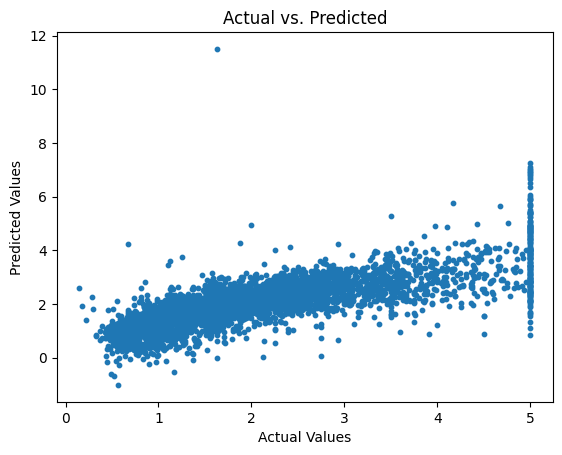

In [11]:
plt.scatter(y_test, y_pred , s=10)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted")
plt.show()


Now we will train the data on random forest

In [12]:
from sklearn.ensemble import RandomForestRegressor


In [13]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [14]:
y_pred_rf = rf_model.predict(X_test)


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MSE: {mse_rf}")
print(f"Random Forest MAE: {mae_rf}")
print(f"Random Forest R2 Score: {r2_rf}")


Random Forest MSE: 0.2553684927247781
Random Forest MAE: 0.32754256845930246
Random Forest R2 Score: 0.8051230593157366


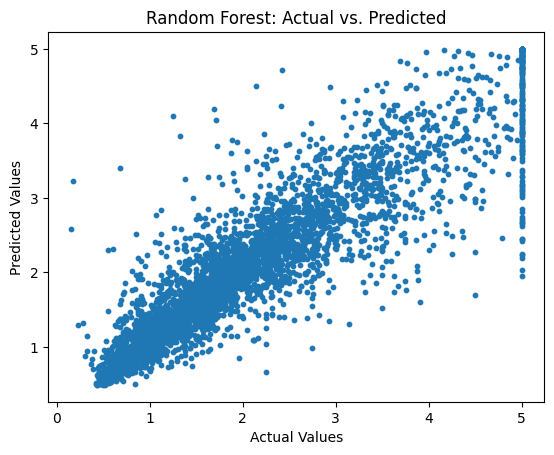

In [16]:
plt.scatter(y_test, y_pred_rf, s=10)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs. Predicted")
plt.show()


Random Forest regression outperforms Linear Regression on this dataset, as shown by lower MSE and MAE values and a higher R² score. This indicates Random Forest’s better ability to capture complex, non-linear relationships in the data, making it a more accurate model for regression tasks.